# Transfer learning

Training a CNN from scratch on ~7,000 images is a hard ask - a lot of
the early-layer work (edges, textures, color gradients) is the same for
any natural image, medical or not. MobileNetV2, pretrained on ImageNet,
already has those early layers. Fine-tuning it here instead of training
from scratch is the standard approach for small/medium image datasets,
and it wasn't attempted before now.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

data = np.load('data/dermamnist_128.npz')
X_train = data['train_images'].astype('float32')
y_train = data['train_labels'].ravel()
X_val = data['val_images'].astype('float32')
y_val = data['val_labels'].ravel()
X_test = data['test_images'].astype('float32')
y_test = data['test_labels'].ravel()

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

with open('outputs/baseline_results.json') as f:
    baseline_results = json.load(f)
with open('outputs/imbalance_results.json') as f:
    imbalance_results = json.load(f)

I0000 00:00:1785472266.933775  548126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785472266.959723  548126 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785472267.967319  548126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


MobileNetV2 expects its own preprocessing (scaled to [-1, 1], not [0, 1]) - using `tf.keras.applications.mobilenet_v2.preprocess_input` rather than the plain `/255.0` used in the earlier notebooks, so the pretrained weights see inputs in the range they were trained on.

In [2]:
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes = 7)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes = 7)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes = 7)

class_weights = compute_class_weight('balanced', classes = np.arange(7), y = y_train)
class_weight_dict = dict(enumerate(class_weights))

def build_transfer_model(input_shape = (128, 128, 3), num_classes = 7, trainable_base = False):
    base = tf.keras.applications.MobileNetV2(
        input_shape = input_shape, include_top = False, weights = 'imagenet')
    base.trainable = trainable_base
    inputs = tf.keras.Input(shape = input_shape)
    x = preprocess(inputs)
    x = base(x, training = False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation = 'softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    return model, base

model, base = build_transfer_model()
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Stage 1: train only the new classification head, base frozen.

In [3]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss', patience = 3, restore_best_weights = True)

history_head = model.fit(
    X_train, y_train_oh,
    validation_data = (X_val, y_val_oh),
    batch_size = 64,
    epochs = 10,
    class_weight = class_weight_dict,
    callbacks = [early_stop],
    verbose = 1,
)

Epoch 1/10


  1/110 ━━━━━━━━━━━━━━━━━━━━ 4:31 2s/step - accuracy: 0.0938 - loss: 2.1852

  2/110 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.1328 - loss: 2.3136

  3/110 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.1771 - loss: 2.1182

  4/110 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.1914 - loss: 2.4327

...

107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6573 - loss: 0.7579

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6586 - loss: 0.7551

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6590 - loss: 0.7570

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.6593 - loss: 0.7563

110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - accuracy: 0.6593 - loss: 0.7563 - val_accuracy: 0.6750 - val_loss: 0.8555


Stage 2: unfreeze the top of the base network and fine-tune at a low learning rate - the standard two-phase transfer learning recipe (train the head first so early fine-tuning gradients aren't huge and random, then unfreeze).

In [4]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(optimizer = tf.keras.optimizers.Adam(1e-5),
              loss = 'categorical_crossentropy', metrics = ['accuracy'])

history_finetune = model.fit(
    X_train, y_train_oh,
    validation_data = (X_val, y_val_oh),
    batch_size = 64,
    epochs = 10,
    class_weight = class_weight_dict,
    callbacks = [tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss', patience = 3, restore_best_weights = True)],
    verbose = 1,
)

Epoch 1/10


  1/110 ━━━━━━━━━━━━━━━━━━━━ 8:10 4s/step - accuracy: 0.5000 - loss: 1.6341

  2/110 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.5781 - loss: 1.6493

  3/110 ━━━━━━━━━━━━━━━━━━━━ 17s 168ms/step - accuracy: 0.5729 - loss: 2.0738

  4/110 ━━━━━━━━━━━━━━━━━━━━ 17s 165ms/step - accuracy: 0.5703 - loss: 2.1959

...

107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6043 - loss: 0.9211

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6042 - loss: 0.9192

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6044 - loss: 0.9200

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6037 - loss: 0.9198

110/110 ━━━━━━━━━━━━━━━━━━━━ 23s 208ms/step - accuracy: 0.6037 - loss: 0.9198 - val_accuracy: 0.6670 - val_loss: 0.8527


In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose = 0)
y_pred = np.argmax(model.predict(X_test, verbose = 0), axis = 1)

print(classification_report(y_test, y_pred, target_names = class_names, digits = 3))

              precision    recall  f1-score   support

       akiec      0.357     0.682     0.469        66
         bcc      0.450     0.573     0.504       103
         bkl      0.469     0.545     0.504       220
          df      0.288     0.739     0.415        23
         mel      0.434     0.547     0.484       223
          nv      0.940     0.755     0.838      1341
        vasc      0.351     0.897     0.505        29

    accuracy                          0.699      2005
   macro avg      0.470     0.677     0.531      2005
weighted avg      0.772     0.699     0.723      2005



In [6]:
per_class_recall = confusion_matrix(y_test, y_pred, normalize = 'true').diagonal()
transfer_result = {
    'test_acc': float(test_acc),
    'macro_f1': float(f1_score(y_test, y_pred, average = 'macro')),
    'weighted_f1': float(f1_score(y_test, y_pred, average = 'weighted')),
    'per_class_recall': {class_names[i]: float(r) for i, r in enumerate(per_class_recall)},
    'params': int(model.count_params()),
}
transfer_result

{'test_acc': 0.6992518901824951,
 'macro_f1': 0.5311966937597355,
 'weighted_f1': 0.7227310358242264,
 'per_class_recall': {'akiec': 0.6818181818181818,
  'bcc': 0.5728155339805825,
  'bkl': 0.5454545454545454,
  'df': 0.7391304347826086,
  'mel': 0.547085201793722,
  'nv': 0.7554064131245339,
  'vasc': 0.896551724137931},
 'params': 2266951}

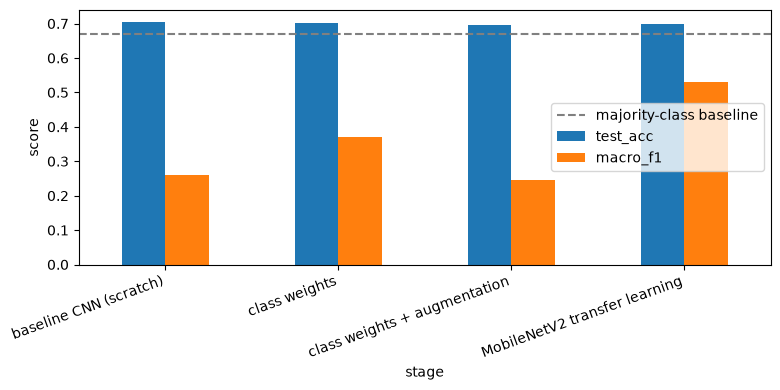

,stage,test_acc,macro_f1
0,baseline CNN (scratch),0.704239,0.258800
1,class weights,0.700249,0.370584
2,class weights + augmentation,0.696758,0.245137
3,MobileNetV2 transfer learning,0.699252,0.531197


In [7]:
stages = pd.DataFrame([
    {'stage': 'baseline CNN (scratch)', 'test_acc': baseline_results['test_acc'],
     'macro_f1': baseline_results['macro_f1']},
    {'stage': 'class weights', 'test_acc': imbalance_results['class_weights']['test_acc'],
     'macro_f1': imbalance_results['class_weights']['macro_f1']},
    {'stage': 'class weights + augmentation',
     'test_acc': imbalance_results['class_weights_augmentation']['test_acc'],
     'macro_f1': imbalance_results['class_weights_augmentation']['macro_f1']},
    {'stage': 'MobileNetV2 transfer learning', 'test_acc': transfer_result['test_acc'],
     'macro_f1': transfer_result['macro_f1']},
])

fig, ax = plt.subplots(figsize = (8, 4))
stages.set_index('stage')[['test_acc', 'macro_f1']].plot.bar(ax = ax)
ax.axhline(baseline_results['majority_baseline_acc'], color = 'gray', linestyle = '--',
           label = 'majority-class baseline')
ax.set_ylabel('score')
ax.set_xticklabels(stages['stage'], rotation = 20, ha = 'right')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/stage_comparison.png', dpi = 120)
plt.show()
stages

In [8]:
os.makedirs('outputs', exist_ok = True)
with open('outputs/transfer_results.json', 'w') as f:
    json.dump(transfer_result, f, indent = 2)

model.save('outputs/transfer_model.keras')